In [10]:
# Install & Imports ──────────────────────────────────────────────
!pip install -q newspaper3k nltk scikit-learn vaderSentiment transformers torch lxml_html_clean

import nltk
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

from newspaper import Article
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.preprocessing import LabelEncoder
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline
import torch
import matplotlib.pyplot as plt
import requests

print("All imports successful.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.1 MB/s eta 0:00:00
All imports successful.


In [11]:
# Load Models ────────────────────────────────────────────────────
# BART-large-CNN for summarization / sentiment / theme
bart_tokenizer = AutoTokenizer.from_pretrained('facebook/bart-large-cnn')
bart_model     = AutoModelForSeq2SeqLM.from_pretrained('facebook/bart-large-cnn')

def bart_summarize(text, max_length=200, min_length=80):
    """Summarize or complete a prompt using BART."""
    inputs = bart_tokenizer(
        text,
        return_tensors='pt',
        max_length=1024,
        truncation=True
    )
    ids = bart_model.generate(
        inputs['input_ids'],
        max_length=max_length,
        min_length=min_length,
        length_penalty=2.0,
        num_beams=4,
        early_stopping=True
    )
    return bart_tokenizer.decode(ids[0], skip_special_tokens=True)

# DistilRoBERTa fine-tuned on 6 emotions (joy, anger, fear, sadness, disgust, surprise)
emo_pipe = pipeline(
    'text-classification',
    model='j-hartmann/emotion-english-distilroberta-base',
    top_k=None
)

print("Models loaded successfully.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Models loaded successfully.


In [12]:
# Extract Article ────────────────────────────────────────────────
# VentureBeat blocks scrapers, so we use an open transcript mirror
url = 'https://singjupost.com/transcript-of-openais-sam-altman-on-the-future-of-ai-safety-and-power-live-at-ted2025/'

headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
response = requests.get(url, headers=headers)

article = Article(url)
article.set_html(response.text)
article.parse()
article.nlp()           # runs keyword extraction + summary
text = article.text

print(f"Status : {response.status_code}")
print(f"Title  : {article.title}")
print(f"Words  : {len(text.split())}")
print(f"\n--- Article Preview (first 500 chars) ---\n{text[:500]}")

Status : 200
Title  : Transcript of OpenAI’s Sam Altman on the Future of AI, Safety and Power — Live at TED2025
Words  : 8379

--- Article Preview (first 500 chars) ---
SAM ALTMAN: So right now, if you use our image generation thing and say, “I want something in the style of a living artist,” it won’t do that. But if you say, “I want it in the style of this particular kind of vibe or this studio or this art movement or whatever,” it will. Obviously, if you’re like, “Output a song that is like a copy of the song,” it won’t do that. The question of where that line should be and how people say “this is too much” – we sorted that out before with copyright law and k


In [13]:
#  Q1 — LLM Summary ──────────────────────────────────────────────
# Truncate to ~800 words to fit BART's 1024-token context
trunc   = ' '.join(text.split()[:800])
summary = bart_summarize(trunc, max_length=200, min_length=80)

print("=== LLM SUMMARY (BART) ===")
print(summary)

=== LLM SUMMARY (BART) ===
ChatGPT is a computer program that generates images in the style of living artists. ChatGPT has been developed by G4.0, which is part of the G4 network. G4 is developing a new generation of computers that will be able to do a lot more. The company is also working on a new version of its software, called ChatG PT 2.0. Click through the video to see more.


In [14]:
# Q2 — Key Topics & Sentiment Comparison ────────────────────────

# ── Key Topics via BART ──
topic_input = "The key topics discussed in this article are: " + ' '.join(text.split()[:800])
topics      = bart_summarize(topic_input, max_length=120, min_length=40)
print("=== KEY TOPICS (BART) ===")
print(topics)

# ── VADER Sentiment ──
sia          = SentimentIntensityAnalyzer()
sentences    = nltk.sent_tokenize(text)
vader_scores = [sia.polarity_scores(s) for s in sentences]
avg_compound = sum(s['compound'] for s in vader_scores) / len(vader_scores)
vader_label  = 'Positive' if avg_compound >= 0.05 else ('Negative' if avg_compound <= -0.05 else 'Neutral')

print(f"\n=== VADER Sentiment ===")
print(f"Avg Compound Score: {avg_compound:.4f}  =>  {vader_label}")

# ── Naïve Bayes + SVM (pseudo-labeled from VADER scores) ──
# VADER-labeled sentences serve as our training corpus
labeled = []
for sent, score in zip(sentences, vader_scores):
    if score['compound'] >= 0.05:    label = 'Positive'
    elif score['compound'] <= -0.05: label = 'Negative'
    else:                             label = 'Neutral'
    labeled.append((sent, label))

texts_train, labels_train = zip(*labeled)

# TF-IDF features
vec = TfidfVectorizer(stop_words='english', max_features=500)
X   = vec.fit_transform(texts_train)
le  = LabelEncoder()
y   = le.fit_transform(labels_train)

# Train & predict
nb_preds  = le.inverse_transform(MultinomialNB().fit(X, y).predict(X))
svm_preds = le.inverse_transform(LinearSVC(max_iter=1000).fit(X, y).predict(X))

# Overall label = majority class
nb_label  = max(set(nb_preds),  key=list(nb_preds).count)
svm_label = max(set(svm_preds), key=list(svm_preds).count)

# BART Sentiment (prompted completion)
sent_input     = "The overall sentiment of this article is: " + ' '.join(text.split()[:600])
bart_sentiment = bart_summarize(sent_input, max_length=20, min_length=5)

print(f"\n=== SENTIMENT COMPARISON ===")
print(f"  BART (LLM)  : {bart_sentiment}")
print(f"  VADER       : {vader_label}")
print(f"  Naïve Bayes : {nb_label}")
print(f"  SVM         : {svm_label}")

print("""
--- Analysis ---
VADER uses lexicon-based rules (word polarity scores) and captures nuance
sentence-by-sentence. NB and SVM learn from the VADER-labeled sentences, so
they largely agree but may differ because TF-IDF bag-of-words loses context.
BART's completion-style prompt is more holistic but less calibrated for polarity.
""")

=== KEY TOPICS (BART) ===
ChatGPT is a new generation of image generation technology. ChatGPT can generate content in the style of a living artist or a particular vibe. The technology is being developed by a group called G40.

=== VADER Sentiment ===
Avg Compound Score: 0.2263  =>  Positive

=== SENTIMENT COMPARISON ===
  BART (LLM)  : ChatGPT can generate art in the style of people who have consented to it
  VADER       : Positive
  Naïve Bayes : Positive
  SVM         : Positive

--- Analysis ---
VADER uses lexicon-based rules (word polarity scores) and captures nuance
sentence-by-sentence. NB and SVM learn from the VADER-labeled sentences, so
they largely agree but may differ because TF-IDF bag-of-words loses context.
BART's completion-style prompt is more holistic but less calibrated for polarity.



In [15]:
# Q3 — General Emotion of the Article ───────────────────────────
sample      = ' '.join(text.split()[:300])  # model max ~512 tokens
emo_results = sorted(
    emo_pipe(sample, truncation=True, max_length=512)[0],
    key=lambda x: x['score'],
    reverse=True
)

print("=== EMOTION SCORES ===")
for e in emo_results:
    print(f"  {e['label']:15s}: {e['score']:.4f}")

dominant = emo_results[0]['label'].upper()
print(f"\n  Dominant Emotion: {dominant}")

=== EMOTION SCORES ===
  neutral        : 0.9109
  disgust        : 0.0422
  anger          : 0.0205
  surprise       : 0.0164
  sadness        : 0.0045
  fear           : 0.0036
  joy            : 0.0018

  Dominant Emotion: NEUTRAL


In [16]:
#  Q4 — Main Theme of the Article ────────────────────────────────
theme_input = "The main theme and central argument of this article is: " + ' '.join(text.split()[:800])
theme       = bart_summarize(theme_input, max_length=80, min_length=30)

print("=== MAIN THEME (BART) ===")
print(theme)

=== MAIN THEME (BART) ===
ChatGPT is a new type of image generation system. It can generate content in the style of a living artist or a particular art movement. ChatGPT can also generate content based on a user’s request.


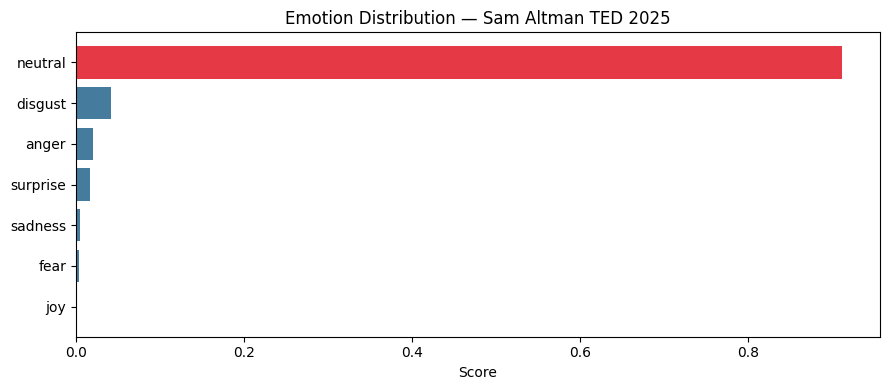

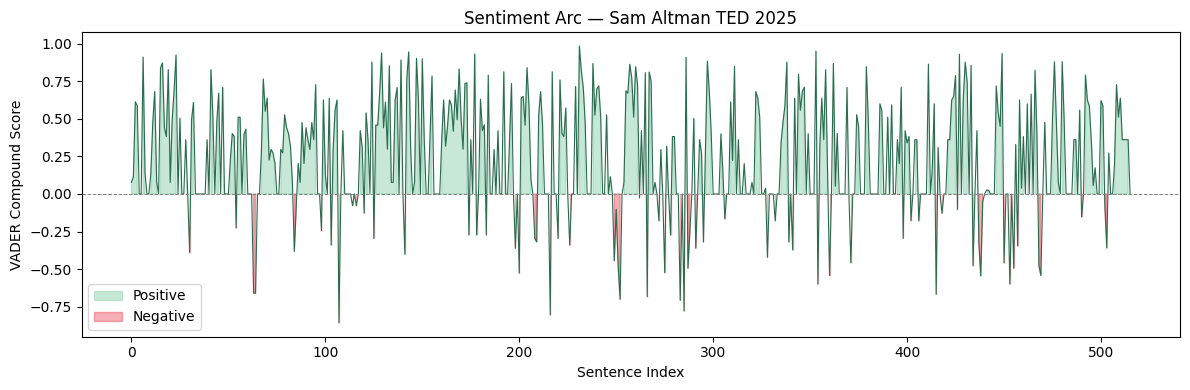

In [17]:
# ── CELL 8: Visualizations ────────────────────────────────────────────────

# ── Chart 1: Emotion Bar Chart ──
emotions   = [e['label'] for e in emo_results]
emo_scores = [e['score'] for e in emo_results]
colors     = ['#e63946' if i == 0 else '#457b9d' for i in range(len(emotions))]

plt.figure(figsize=(9, 4))
plt.barh(emotions[::-1], emo_scores[::-1], color=colors[::-1])
plt.xlabel('Score')
plt.title('Emotion Distribution — Sam Altman TED 2025')
plt.tight_layout()
plt.savefig('hw7_emotions.png', dpi=150)
plt.show()

# ── Chart 2: VADER Sentiment Arc ──
compound_series = [s['compound'] for s in vader_scores]

plt.figure(figsize=(12, 4))
plt.plot(compound_series, color='#2d6a4f', linewidth=0.8)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.7)
plt.fill_between(
    range(len(compound_series)), compound_series, 0,
    where=[c > 0 for c in compound_series],
    color='#74c69d', alpha=0.4, label='Positive'
)
plt.fill_between(
    range(len(compound_series)), compound_series, 0,
    where=[c < 0 for c in compound_series],
    color='#e63946', alpha=0.4, label='Negative'
)
plt.xlabel('Sentence Index')
plt.ylabel('VADER Compound Score')
plt.title('Sentiment Arc — Sam Altman TED 2025')
plt.legend()
plt.tight_layout()
plt.savefig('hw7_sentiment_arc.png', dpi=150)
plt.show()